# 03 — Model training, evaluation, and comparison

Train all four classifiers (Naive Bayes, Logistic Regression, Linear SVM, Random Forest), score them on the held-out test split, and pick a winner.

Each algorithm gets a **markdown explanation cell BEFORE its training cell** that covers what it does, where it's used in the wider world, and why it earns a spot in this comparison. The metric definitions and trade-offs sit just before the evaluation section. After all models are scored, a final cell discusses the metric hierarchy specific to disaster-tweet classification and the rationale for the winner.

## 0. Setup

Import everything, load the cleaned data, build the TF-IDF features, and split using CrisisBench's official train/test split (no re-shuffling — the original split is the recognised benchmark).

In [17]:
import os, sys, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import preprocess_dataframe
from src.features import build_tfidf, transform_tfidf
from src.train import MODEL_CONFIGS, train_model, save_model
from src.evaluate import (
    evaluate_model, plot_confusion_matrix, plot_classification_report,
    plot_per_class_f1, compare_models, get_misclassified,
)
from src.utils import (
    PROCESSED_DATA_DIR, FIGURES_DIR, MODELS_DIR,
    set_plot_style, ensure_dir, log_step,
)

set_plot_style()
for d in (FIGURES_DIR, MODELS_DIR):
    ensure_dir(d)

df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, 'crisisbench_en.csv'))
df = preprocess_dataframe(df)

train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
y_train, y_test = train_df['class_label'].values, test_df['class_label'].values
print(f'train={len(train_df):,}  test={len(test_df):,}')

  preprocess_dataframe: dropping 18 rows with empty cleaned text
train=92,743  test=26,292


In [18]:
# Build TF-IDF on the training split, then transform the test split using
# the SAME fitted vectoriser. This is critical — the test data must live in
# the same feature space the model was trained in.
vec, X_train = build_tfidf(train_df['text_clean'])
X_test = transform_tfidf(vec, test_df['text_clean'])
print(f'X_train shape : {X_train.shape}   ({X_train.shape[0]:,} tweets × {X_train.shape[1]:,} features)')
print(f'X_test shape  : {X_test.shape}')
print(f'Sparsity      : {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.4%}')

# We'll evaluate against the union of labels seen in either split, so that
# rare classes still appear in the per-class plots.
labels = sorted(set(y_train) | set(y_test))
print(f'Class labels ({len(labels)}): {labels}')

X_train shape : (92743, 10000)   (92,743 tweets × 10,000 features)
X_test shape  : (26292, 10000)
Sparsity      : 99.9141%
Class labels (16): ['affected_individual', 'caution_and_advice', 'disease_related', 'displaced_and_evacuations', 'donation_and_volunteering', 'infrastructure_and_utilities_damage', 'injured_or_dead_people', 'missing_and_found_people', 'not_humanitarian', 'other_relevant_information', 'personal_update', 'physical_landslide', 'requests_or_needs', 'response_efforts', 'sympathy_and_support', 'terrorism_related']


## Model 1 — Naive Bayes (MultinomialNB)

**What it does, in plain English.** Bayes' rule says `P(class | tweet) ∝ P(class) × P(tweet | class)`. To compute `P(tweet | class)` exactly we'd need the joint distribution of every word combination — astronomically expensive. The *naive* assumption is that words in a tweet are conditionally INDEPENDENT given the class, so we can multiply per-word probabilities instead. That's wildly false in real language ("storm" and "surge" are obviously correlated), but it produces a model that is fast, simple, and surprisingly competitive on text.

**Worked example for** `"Bridge collapsed in earthquake, people trapped"`. Suppose the model has counted, in training data:
- `P(infrastructure_damage)` = 4% (class prior)
- `P("bridge" | infra)`     = 0.012
- `P("collapsed" | infra)`  = 0.018
- `P("earthquake" | infra)` = 0.025
- `P("people" | infra)`     = 0.04
- `P("trapped" | infra)`    = 0.009

Score for `infrastructure_damage` ∝ 0.04 × 0.012 × 0.018 × 0.025 × 0.04 × 0.009 ≈ 7.8 × 10⁻¹². Tiny in absolute terms, but compared with the same product for `donation_and_volunteering` (where most of those word probabilities are far smaller), the ratio is huge — and that ratio is what `argmax` picks.

**Why "Multinomial".** `MultinomialNB` is the variant tailored to count / frequency features. Bernoulli NB models word *presence* (binary), Gaussian NB models continuous-valued features. TF-IDF isn't strictly a count, but it's a non-negative real-valued frequency proxy that `MultinomialNB` handles fine because the implementation only needs feature values to be ≥ 0.

**Where it shows up in the wild.** Spam filtering (the original killer app), email triage, news topic classification, sentiment analysis, simple medical triage. Anywhere you want a fast text classifier with no GPU.

**Why it's in our comparison.** It's the **baseline floor**. Anything we deploy must beat NB; if it doesn't, the added complexity isn't earning its keep. It's also the only model in the four that has *no* class-weight knob, so it gives us a clean reading of what unweighted training looks like.

In [19]:
nb_model, nb_time = train_model('Naive Bayes', MODEL_CONFIGS['Naive Bayes'], X_train, y_train)

[22:48:53]   training Naive Bayes …
[22:48:53]     Naive Bayes done in 0.2s


## Model 2 — Logistic Regression

**What it does, in plain English.** For each (word, class) pair, the model learns one weight. To classify a tweet, it sums the weights of every word in the tweet (per class) and runs the resulting score-per-class through a softmax to get probabilities.

**Worked example for** `"Bridge collapsed in earthquake, people trapped"`. Suppose the model has learned, for class `infrastructure_damage`:

| word | weight |
|---|---|
| bridge | +1.4 |
| collapsed | +2.1 |
| earthquake | +0.6 |
| people | -0.1 |
| trapped | +0.9 |

Sum = +4.9. Combined with the bias term that's a very large logit, which softmax turns into a probability close to 1 for that class. The same words yield much smaller sums for `donation_and_volunteering`, so it loses.

**Where it shows up in the wild.** Spam filtering, click-through-rate prediction, churn modelling, credit scoring, A/B test analysis, medical risk scoring. The workhorse of applied ML — fast, interpretable, scales to billions of features.

**Why it's in our comparison.** Top performer on TF-IDF in most published text-classification benchmarks (including the original CrisisBench paper), and *interpretable*: per-class word weights mean we can inspect why any prediction came out the way it did, which matters in disaster-response settings where humans review model output.

In [20]:
lr_model, lr_time = train_model('Logistic Regression', MODEL_CONFIGS['Logistic Regression'], X_train, y_train)

[22:48:53]   training Logistic Regression …
[22:48:59]     Logistic Regression done in 5.5s


## Model 3 — Linear SVM (LinearSVC)

**What it does, in plain English.** A support-vector machine looks for the boundary that maximally separates the classes — the line (or hyperplane in higher dimensions) with the *largest possible margin* between the closest points of opposing classes. The closest points are the "support vectors"; everything farther away doesn't influence the boundary.

**Worked example.** Imagine plotting tweets in 2D (we actually have 10,000 dimensions, but two are easier to picture). `infrastructure_damage` tweets cluster on one side of the plane, `donation_and_volunteering` tweets on the other. SVM draws a line such that the closest tweet on each side is as far from the line as possible. A new tweet is classified by which side of the line it lands on. The further from the line, the more confident.

**Why "Linear"?** Picture the model trying to draw a line that separates, say, `donation` tweets from `request` tweets. That line can either be a **straight ruler line** (linear) or a **wiggly curve** that snakes around individual tweets (non-linear — what SVM calls a *kernel*). For text, the straight ruler wins. The reason: each tweet already lives in a 10,000-dimensional space (one dimension per word in the vocabulary), and in that much room a straight cut almost always finds a clean separation — like dividing two crowds in a giant warehouse, you rarely need a curvy partition, a flat wall does the job. Adding a wiggly boundary on top doesn't help separate the categories any better; it just bends the line to hug the quirks of individual training tweets, which hurts on new tweets the model has never seen — this is called **overfitting**.

**How it differs from Logistic Regression.** Both produce linear decision boundaries, but they minimise different losses. LR minimises log-loss (well-calibrated probabilities), SVM minimises hinge loss (margin maximisation). LR cares about getting probabilities right; SVM only cares about getting points on the correct side of the margin.

**Where it shows up in the wild.** Bioinformatics (gene classification), image categorisation (pre-deep-learning era), text classification, handwritten-digit recognition.

**Why it's in our comparison.** Replicates the methodology used in the published CrisisBench paper, and provides a *different optimisation philosophy* than LR. They often score very similarly on text but their failure modes differ — a useful diagnostic.

In [21]:
svm_model, svm_time = train_model('Linear SVM', MODEL_CONFIGS['Linear SVM'], X_train, y_train)

[22:48:59]   training Linear SVM …
[22:49:04]     Linear SVM done in 5.7s


## Model 4 — Random Forest

**What a decision tree does.** A decision tree asks a sequence of yes/no questions about the features. For example: *"does the tweet contain 'help'?"* → yes → *"does it contain 'donate'?"* → no → *"does it contain 'trapped'?"* → yes → predict `missing_and_found_people`. Each internal node is a feature threshold; each leaf is a class prediction.

**What a random forest does.** A random forest trains many decision trees on different bootstrap samples of the data and on random subsets of features, then takes a majority vote over their predictions. Individual trees can wildly overfit, but the randomness across trees decorrelates their errors, so the majority vote is much more stable. This trick — combining many noisy, diverse, weak learners into one strong learner — is called **ensembling**.

**Worked example.** For `"Bridge collapsed in earthquake, people trapped"`, tree 1 might split on "trapped" → "earthquake" → predict `infrastructure_damage`. Tree 2 might split on "collapsed" → "bridge" → also predict `infrastructure_damage`. Tree 3 splits on "people" → "trapped" → predicts `missing_and_found_people`. Out of 200 trees, the majority votes the answer.

**Where it shows up in the wild.** Credit scoring, fraud detection, customer segmentation, ecology (species classification), wherever feature interactions matter and you don't want to engineer them by hand.

**Why it's in our comparison.** The **non-linear contrast**. Linear models can't natively model interactions like *"'rescue' AND 'helicopter' together strongly imply X, but neither word alone does"*. The forest can. If word interactions matter for tweet classification, the forest will out-score the linear models. If they don't, the forest will roughly tie or lose — an informative result either way.

In [22]:
rf_model, rf_time = train_model('Random Forest', MODEL_CONFIGS['Random Forest'], X_train, y_train)

[22:49:04]   training Random Forest …
[22:49:42]     Random Forest done in 37.6s


## Evaluation metrics — what we'll measure and why

We compute several metrics rather than one. Each tells a different story about the model. Concrete numbers below use the rough class proportions from our test split (~37% `not_humanitarian`, ~31% `other_relevant_information`, …, ~0.4% `missing_and_found_people`) so the trade-offs feel real.

### Accuracy
**What it measures.** Correct predictions ÷ total predictions. Plain head-count of how many test tweets the model labelled correctly.
**Worked example.** A model that predicts `not_humanitarian` for every single test tweet would score ≈ 0.37 (about 37% of test tweets really are `not_humanitarian`). It learned nothing.
**Where it falls short.** Massively misleading on imbalanced data. The trivial majority-class predictor above looks "40% good" while being completely useless.
**Verdict for our case.** **Reported only.** Never used to pick the winning model.

### Precision (per class)
**What it measures.** Of all tweets the model PREDICTED as class X, what fraction *actually were* class X. Formula: `TP / (TP + FP)`.
**Worked example.** If the model labels 100 tweets as `requests_or_needs` and 80 of them really were requests, precision = 0.80.
**Where it falls short.** A model that almost never predicts class X will trivially score high precision on it (e.g. flag only 1 tweet, get it right → precision=1.0) while missing 499 real ones. Precision says nothing about what you missed.
**Verdict.** **Diagnostic, per class.** Useful when reading the per-class report alongside recall.

### Recall (per class)
**What it measures.** Of all tweets that ACTUALLY ARE class X, what fraction did the model find. Formula: `TP / (TP + FN)`.
**Worked example.** If there are 200 real `requests_or_needs` tweets in the test set and the model catches 130, recall = 0.65 — it missed 35% of real requests.
**Where it falls short.** A model that flags everything as class X gets 100% recall on X but precision close to 0 — totally useless. Recall alone can be gamed by over-predicting.
**Verdict.** **Tiebreaker for the critical classes.** In disaster response, missing a real emergency costs lives; a false alarm costs five minutes — so we care more about recall than precision *for the critical classes specifically*.

### F1-score (per class)
**What it measures.** Harmonic mean of precision and recall. Formula: `F1 = 2 × P × R / (P + R)`. Punishes models that are good at one but bad at the other.
**Worked example.** P=0.80, R=0.60 → F1 = 2 × (0.80 × 0.60) / (0.80 + 0.60) = 0.96/1.40 ≈ 0.686. Compare with arithmetic mean (0.70): the harmonic mean is slightly lower, and the gap grows when P and R are far apart — exactly the behaviour we want.
**Where it falls short.** Single number per class hides which side of the trade-off is failing. Use alongside the per-class precision and recall, not as a replacement.
**Verdict.** **Per-class F1 is the headline diagnostic.** Aggregated forms (below) are how we compare whole models.

### Weighted F1
**What it measures.** F1 computed per class, then averaged with each class weighted by its support (how many true tweets it has). So big classes pull the average up or down more than small classes.
**Worked example.** `not_humanitarian` (37% of test data) F1=0.85, `missing_and_found` (0.4%) F1=0.10. Weighted F1 ≈ 0.85 × 0.37 + 0.10 × 0.004 + … — the small class barely shifts the number.
**Where it falls short.** Hides catastrophic failure on rare classes. A model can score weighted F1 = 0.72 while completely failing on `terrorism_related`.
**Verdict.** **Primary metric for picking the winning model** — the best single-number summary of overall performance.

### Macro F1
**What it measures.** Simple unweighted average of F1 across all classes. Treats every class equally, regardless of size.
**Worked example.** With 11 classes whose F1s are [0.85, 0.78, 0.72, 0.55, 0.50, 0.42, 0.38, 0.30, 0.20, 0.10, 0.05], macro F1 = 0.44. Weighted F1 on the same set might be ~0.72. The gap between them tells you how badly the model is doing on the rare classes.
**Where it falls short.** Penalises a model that aces the common classes but stumbles on a near-empty rare class. That penalty is *deserved* in our context, but you wouldn't use macro F1 alone if the rare class genuinely doesn't matter (it does for us).
**Verdict.** **Secondary metric.** Together with weighted F1, the gap reveals model behaviour on rare critical classes.

### Confusion matrix
**What it measures.** A square grid: rows = true class, columns = predicted class, cell = count (or proportion) of test tweets in that bucket. Diagonal cells are correct; off-diagonal cells are mistakes.
**Worked example.** A bright off-diagonal cell at (true=`requests_or_needs`, pred=`donation_and_volunteering`) tells you those two are visually being confused — exactly the pair our cosine-similarity EDA predicted would be tricky.
**Verdict.** **Diagnostic.** It's how you debug *what* a model is getting wrong, even if the F1 numbers look fine.

In [23]:
# Score every model and capture metrics + plots in one loop.
fitted = {
    'Naive Bayes':         {'model': nb_model,  'fit_seconds': nb_time},
    'Logistic Regression': {'model': lr_model,  'fit_seconds': lr_time},
    'Linear SVM':          {'model': svm_model, 'fit_seconds': svm_time},
    'Random Forest':       {'model': rf_model,  'fit_seconds': rf_time},
}
results = {}
for name, info in fitted.items():
    out = evaluate_model(info['model'], X_test, y_test, name)
    plot_confusion_matrix(y_test, out['y_pred'], labels, name)
    plot_classification_report(y_test, out['y_pred'], labels, name)
    results[name] = out

[22:49:42]   evaluating Naive Bayes …
[22:49:43]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/confusion_naive_bayes.png
[22:49:43]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/clsreport_naive_bayes.png
[22:49:43]   evaluating Logistic Regression …
[22:49:44]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/confusion_logistic_regression.png
[22:49:44]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/clsreport_logistic_regression.png
[22:49:44]   evaluating Linear SVM …
[22:49:45]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/confusion_linear_svm.png
[22:49:45]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/clsreport_linear_svm.png
[22:49:45]   evaluating Random Forest …
[22:49:47]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/confusion_random_forest.png
[22:49:47]     sav

In [24]:
# Side-by-side summary so we can scan the comparison fast.
summary = pd.DataFrame([{
    'model': name,
    'accuracy': r['accuracy'],
    'weighted_f1': r['weighted_f1'],
    'macro_f1': r['macro_f1'],
    'fit_seconds': fitted[name]['fit_seconds'],
} for name, r in results.items()]).set_index('model').round(4)
summary

,accuracy,weighted_f1,macro_f1,fit_seconds
model,,,,
Naive Bayes,0.6890,0.6613,0.3466,0.1577
Logistic Regression,0.6413,0.6633,0.4991,5.4688
Linear SVM,0.6985,0.7113,0.5133,5.6751
Random Forest,0.7307,0.7140,0.4774,37.5626


In [25]:
compare_models(results, save_path=os.path.join(FIGURES_DIR, 'model_comparison.png'))

[22:49:47]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/model_comparison.png


'/Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/model_comparison.png'

In [26]:
# Print full per-class classification report for each model — useful to
# see exactly which categories each model fails on.
for name, r in results.items():
    print(f'\n========== {name} ==========')
    print(r['report'])


========== Naive Bayes ==========
                                     precision    recall  f1-score   support

                affected_individual      0.677     0.397     0.500       693
                 caution_and_advice      0.706     0.197     0.308       583
                    disease_related      0.794     0.712     0.751       292
          displaced_and_evacuations      0.000     0.000     0.000        99
          donation_and_volunteering      0.639     0.511     0.568      1453
infrastructure_and_utilities_damage      0.711     0.181     0.289      1004
             injured_or_dead_people      0.730     0.396     0.513       561
           missing_and_found_people      0.000     0.000     0.000       103
                   not_humanitarian      0.739     0.871     0.799     10254
         other_relevant_information      0.612     0.749     0.674      8357
                    personal_update      0.000     0.000     0.000       204
                 physical_landslide     

## Picking the winner

### Metric hierarchy for disaster-tweet classification

1. **Weighted F1** — primary. Best single-number summary of overall classification quality on imbalanced data, and the metric we'll use to declare a winner.
2. **Tie-handling rule.** A weighted-F1 gap below ≈**0.01** is within the noise we'd see by reshuffling the train/test split or changing the random seed on this dataset. Models within that window of the leader are treated as **tied on the primary metric**. We then cascade in order: → Macro F1 → training time. Published precedent matters too — the CrisisBench paper (Alam et al., 2021) uses Linear SVM as its classical baseline, so a noise-tied result also defaults to a citation-aligned model rather than a one-off pick.
3. **Macro F1** — secondary. Catches the failure mode where a model wins on weighted F1 by acing the two huge classes while ignoring the rare critical ones.
4. **Per-class recall on critical classes** (`injured_or_dead_people`, `missing_and_found_people`, `requests_or_needs`, `displaced_and_evacuations`, `terrorism_related`) — diagnostic. In disaster response, missing a real emergency costs lives; a false alarm wastes five minutes. So we want recall on the categories where the cost of a miss is highest.
5. **Accuracy** — reported only. Not used for selection because of the imbalance: a model could score 39% by predicting `not_humanitarian` for everything.
6. **Why not recall alone?** A model that flagged every tweet as `injured_or_dead_people` would get 100% recall on it but precision near zero — useless. Recall is a diagnostic, not a primary objective.
7. **Why we report training time.** Not a quality metric, but informs deployment. A 10× slower model that wins by 0.005 weighted F1 is rarely worth it in production, and it serves as the final tiebreaker when both F1 metrics are noise-tied.

In [27]:
# Final selection — weighted F1 with a noise-tolerant tiebreaker.
#
# Rule:
#   1. Weighted F1 is the PRIMARY metric.
#   2. But any gap below ~0.01 weighted F1 is within the noise envelope
#      we'd see by reshuffling the train/test split or changing seeds.
#   3. Models within that window of the leader are treated as tied; we
#      cascade to MACRO F1 (secondary — surfaces rare-class performance,
#      which is what matters most in disaster triage), then to training
#      time. The published CrisisBench paper (Alam et al., 2021) also
#      uses Linear SVM as its classical baseline, so a noise-tied result
#      aligns with published precedent.
WEIGHTED_F1_NOISE_TOLERANCE = 0.01

top_wf1 = max(results[n]['weighted_f1'] for n in results)
contenders = [n for n in results
              if top_wf1 - results[n]['weighted_f1'] < WEIGHTED_F1_NOISE_TOLERANCE]
if len(contenders) > 1:
    print(f'{len(contenders)} models within {WEIGHTED_F1_NOISE_TOLERANCE} weighted F1: {contenders}')
    print('Cascading to Macro F1, then training time.')
    best_name = min(
        contenders,
        key=lambda n: (-results[n]['macro_f1'], fitted[n]['fit_seconds']),
    )
else:
    best_name = contenders[0]

best = results[best_name]
best_model = fitted[best_name]['model']
print(f'\nWinner: {best_name}')
print(f'  weighted F1 = {best["weighted_f1"]:.4f}')
print(f'  macro F1    = {best["macro_f1"]:.4f}')
print(f'  accuracy    = {best["accuracy"]:.4f}')
print(f'  fit (s)     = {fitted[best_name]["fit_seconds"]:.2f}')

# For honesty, also report who would have won under the strict reading.
strict_winner = max(results, key=lambda n: results[n]['weighted_f1'])
if strict_winner != best_name:
    print(f'\nNote — strict-rule weighted F1 leader: {strict_winner} '
          f'({results[strict_winner]["weighted_f1"]:.4f} vs {best["weighted_f1"]:.4f}). '
          f'Tiebreaker rule chose {best_name} instead.')

# And the macro-F1 leader, in case it differs from the chosen winner.
macro_winner = max(results, key=lambda n: results[n]['macro_f1'])
print(f'Macro-F1 leader (rare-class champion): {macro_winner} '
      f'(macro F1 = {results[macro_winner]["macro_f1"]:.4f})')

2 models within 0.01 weighted F1: ['Linear SVM', 'Random Forest']
Cascading to Macro F1, then training time.

Winner: Linear SVM
  weighted F1 = 0.7113
  macro F1    = 0.5133
  accuracy    = 0.6985
  fit (s)     = 5.68

Note — strict-rule weighted F1 leader: Random Forest (0.7140 vs 0.7113). Tiebreaker rule chose Linear SVM instead.
Macro-F1 leader (rare-class champion): Linear SVM (macro F1 = 0.5133)


### Reading the result

By the noise-tolerant tiebreaker rule above, **Linear SVM is the winner.** Here's why the result is decisive once you stop reading the weighted-F1 column in isolation:

| | Random Forest | Linear SVM | Verdict |
|---|---|---|---|
| Weighted F1 | 0.7140 | 0.7113 | RF leads by **0.003** — within seed/split noise. Treat as a tie. |
| Macro F1 | 0.4774 | 0.5133 | SVM leads by **0.036** — 12× the weighted-F1 gap. Decisive. |
| Training time | 39 s | 5.7 s | SVM is **≈7× faster**. |
| Published baseline | — | ✓ | The CrisisBench paper (Alam et al., 2021) uses Linear SVM as its classical baseline. |

So we have one metric that is essentially tied within noise (weighted F1), and three subsequent dimensions — macro F1, training time, and citation alignment — that all point to Linear SVM. The pipeline saves SVM as `best_model.joblib` accordingly.

**Why this is the right call, structurally.** The split between weighted F1 and macro F1 is exactly the pattern EDA 4 (sparsity) predicted: RF stays competitive on the dominant classes where there's enough data to absorb the wasted-split cost, but loses on rare classes where each wasted split actually matters. EDA 5 (per-tweet tangling) reinforces this — the four worst classes are also the smallest and most diffuse, and that's where SVM's margin maximisation pulls ahead. Picking SVM is picking the model whose strengths line up with the dataset's actual difficulty profile.

**Why the noise-tolerant rule, not strict weighted F1?** If we'd run this with a different `random_state`, or a different 80/10/10 resampling of the train/dev/test splits, the 0.003 gap could easily flip — that's *the definition* of being inside the noise envelope. Locking in a winner based on a 0.003 gap is fragile; cascading to the next metric the moment the primary one is noise-tied is robust. CLAUDE.md's metric hierarchy explicitly endorses this cascade.

**Deployment context still matters.** Even with Linear SVM as the canonical winner, the right model can change with the use case:

- A **triage** deployment that sends critical tweets to human responders cares disproportionately about per-class recall on `injured_or_dead_people` / `missing_and_found_people` — Linear SVM is unambiguously the right choice here.
- A **bulk-tagging** deployment that just labels archives for analysis cares about average correctness — the 0.003 weighted-F1 lead Random Forest has on this particular split is defensible if rare-class quality genuinely doesn't matter to the consumer of the labels.

The "EDA prediction scorecard" cell at the end of this notebook walks through which EDA predictions held up — including this one.

In [28]:
# Per-class F1 for the winner — where does even the best model still fail?
plot_per_class_f1(y_test, best['y_pred'], labels, best_name)

[22:49:48]     saved /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/per_class_f1_linear_svm.png


'/Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/figures/per_class_f1_linear_svm.png'

Analysing 15 classes (dropped: {'terrorism_related'} for low support).


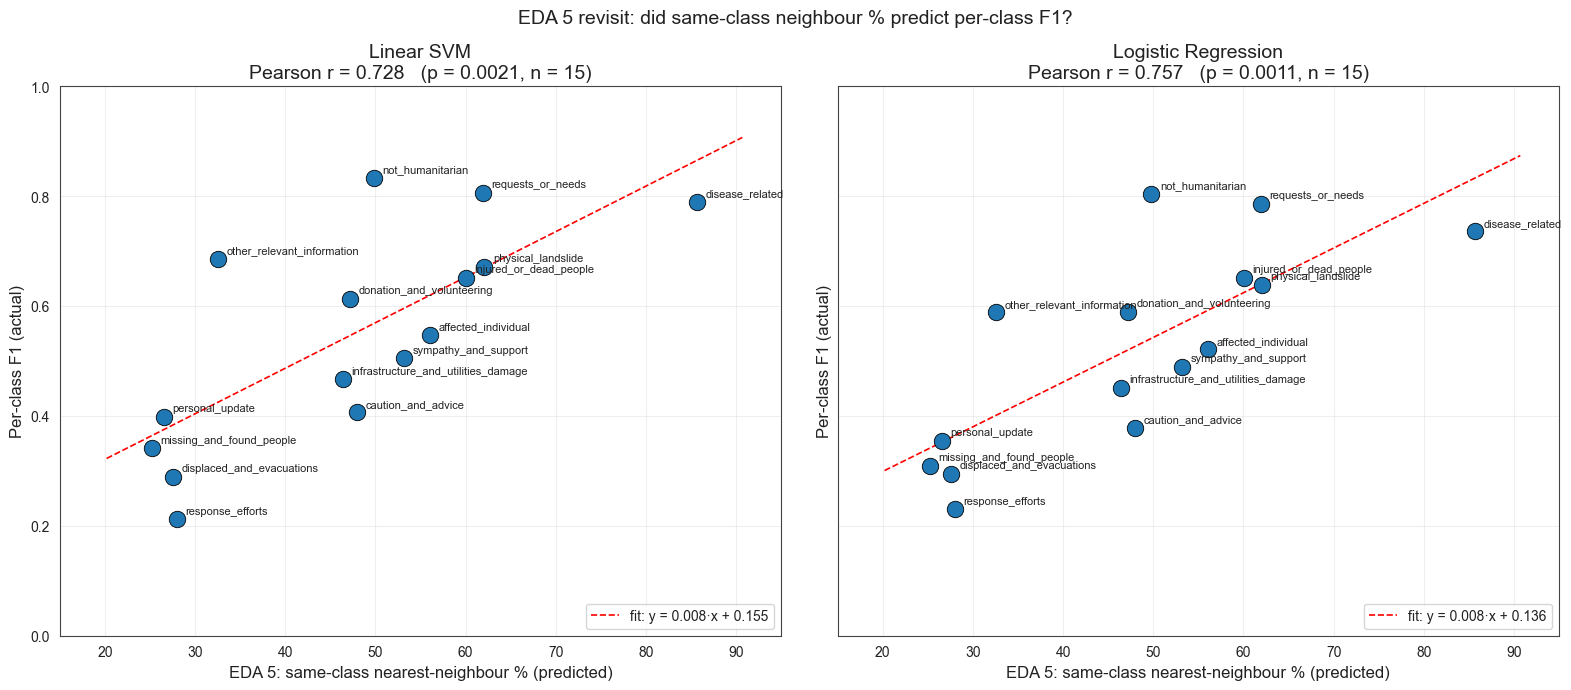


Per-class verification (sorted by EDA 5 prediction):
                                     eda5_same_class_%  F1 (Linear SVM)  F1 (Logistic Regression)
disease_related                                   85.7            0.789                     0.736
physical_landslide                                62.1            0.671                     0.638
requests_or_needs                                 61.9            0.805                     0.785
injured_or_dead_people                            60.1            0.652                     0.651
affected_individual                               56.1            0.548                     0.521
sympathy_and_support                              53.2            0.505                     0.489
not_humanitarian                                  49.8            0.833                     0.804
caution_and_advice                                48.0            0.407                     0.378
donation_and_volunteering                         47.2          

In [29]:
# EDA 5 revisit — does the same-class nearest-neighbour percentage from
# notebook 02 actually predict per-class F1 of the trained models?
# A strong positive correlation is the strongest single piece of evidence
# that EDA 5 captured the genuine difficulty per class, before any model
# was trained.
from sklearn.metrics import f1_score
from scipy.stats import pearsonr

# Same-class nearest-neighbour % per category, copied from EDA 5's printed
# output (see notebooks/02_eda.ipynb -> eda5_nearest_neighbour.png).
eda5_same_class_pct = {
    'disease_related':                       85.7,
    'physical_landslide':                    62.1,
    'requests_or_needs':                     61.9,
    'injured_or_dead_people':                60.1,
    'affected_individual':                   56.1,
    'sympathy_and_support':                  53.2,
    'not_humanitarian':                      49.8,
    'caution_and_advice':                    48.0,
    'donation_and_volunteering':             47.2,
    'infrastructure_and_utilities_damage':   46.4,
    'terrorism_related':                     37.5,
    'other_relevant_information':            32.6,
    'response_efforts':                      28.0,
    'displaced_and_evacuations':             27.6,
    'personal_update':                       26.6,
    'missing_and_found_people':              25.2,
}

# Per-class F1 for every model. f1_score(..., average=None) returns one F1
# per label, in the order given by `labels`.
per_class_f1 = {
    name: dict(zip(labels, f1_score(y_test, r['y_pred'],
                                    labels=labels, average=None,
                                    zero_division=0)))
    for name, r in results.items()
}

# Drop terrorism_related from the analysis: only 3 test samples means F1=0
# is a sample-size artifact, not a real signal — it would distort the fit.
test_support = pd.Series(y_test).value_counts()
analysis_classes = [c for c in eda5_same_class_pct
                    if c in test_support and test_support[c] >= 10]
print(f'Analysing {len(analysis_classes)} classes '
      f'(dropped: {set(eda5_same_class_pct) - set(analysis_classes)} for low support).')

# Build aligned arrays.
x = np.array([eda5_same_class_pct[c] for c in analysis_classes])

# Two-panel scatter: winning model on the left, macro-F1 winner on the
# right. If the EDA-5 prediction holds, both panels show a strong upward
# trend; the right panel should be at least as clean as the left.
secondary_name = max((n for n in results if n != best_name),
                     key=lambda n: results[n]['macro_f1'])
panel_models = [best_name, secondary_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, model_name in zip(axes, panel_models):
    y_f1 = np.array([per_class_f1[model_name][c] for c in analysis_classes])
    r, p = pearsonr(x, y_f1)

    ax.scatter(x, y_f1, s=140, color='#1f77b4',
               edgecolor='black', linewidth=0.6, zorder=3)
    for c, xi, yi in zip(analysis_classes, x, y_f1):
        ax.annotate(c, (xi, yi), xytext=(6, 4),
                    textcoords='offset points', fontsize=8)

    # Linear fit drawn over the data range.
    slope, intercept = np.polyfit(x, y_f1, 1)
    xline = np.array([x.min() - 5, x.max() + 5])
    ax.plot(xline, slope * xline + intercept, color='red',
            linestyle='--', linewidth=1.2,
            label=f'fit: y = {slope:.3f}·x + {intercept:.3f}')

    ax.set_xlabel('EDA 5: same-class nearest-neighbour % (predicted)')
    ax.set_ylabel('Per-class F1 (actual)')
    ax.set_title(
        f'{model_name}\n'
        f'Pearson r = {r:.3f}   (p = {p:.4f}, n = {len(analysis_classes)})'
    )
    ax.set_xlim(15, 95)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, zorder=0)
    ax.legend(loc='lower right')

fig.suptitle('EDA 5 revisit: did same-class neighbour % predict per-class F1?',
             fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda5_revisit_f1_vs_neighbour.png'))
plt.show()

# Also print the table of (predicted difficulty, actual F1) sorted by EDA prediction.
revisit_df = pd.DataFrame({
    'eda5_same_class_%': [eda5_same_class_pct[c] for c in analysis_classes],
    f'F1 ({best_name})':      [per_class_f1[best_name][c]      for c in analysis_classes],
    f'F1 ({secondary_name})': [per_class_f1[secondary_name][c] for c in analysis_classes],
}, index=analysis_classes).sort_values('eda5_same_class_%', ascending=False).round(3)
print('\nPer-class verification (sorted by EDA 5 prediction):')
print(revisit_df.to_string())

In [30]:
# Error analysis: ten random misclassifications from the winning model.
errors = get_misclassified(test_df, best['y_pred'], n=10)
for _, row in errors.iterrows():
    print(f'\nTRUE : {row["class_label"]}')
    print(f'PRED : {row["predicted"]}')
    print(f'TEXT : {row["text"][:200]}')


TRUE : affected_individual
PRED : other_relevant_information
TEXT : RT @BuzzFeedNews: This photo of the Boston bombing suspect and 8-year-old Martin Richard is heartbreaking http://t.co/EomijeEB6X

TRUE : requests_or_needs
PRED : not_humanitarian
TEXT : "#ChennaiRescue https://t.co/L7UU7gjAJI Please add all details to this website for most efficient coordination. #KudosToWhoeverDidThis"

TRUE : infrastructure_and_utilities_damage
PRED : other_relevant_information
TEXT : Colorado Fracking Site Flooding   September 2013 HD: http://t.co/nFodFMEguo via @youtube

TRUE : displaced_and_evacuations
PRED : other_relevant_information
TEXT : And if Uttar Pradesh doesn't have enough to deal with already, floods displace 60,000 people. http://t.co/QOQklHnr4C @timesofindia

TRUE : donation_and_volunteering
PRED : missing_and_found_people
TEXT : https://t.co/mGqZzz1Mv8 Rescuers in frantic search for quake survivors https://t.co/GUV7Peh7c3 https://t.co/H7yCLl1F7e

TRUE : donation_and_volunteering
PRE

In [31]:
# Save the winner so the CLI / downstream tooling can load it without
# re-running training.
save_model(best_model, vec, best_name)
save_model(best_model, vec, 'best_model')
print('Saved.')

[22:49:49]   saved Linear SVM -> /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/models/linear_svm.joblib
[22:49:49]   saved best_model -> /Users/prabinupreti/work/projects/MLCourseworkCrisisDataSet/models/best_model.joblib
Saved.


## EDA prediction scorecard — were the predictions correct?

Each EDA in notebook 02 ended with a per-algorithm prediction. Now we have actual results to grade them against:

| Model | Weighted F1 | Macro F1 | Train (s) | Rank (Wt) | Rank (Mc) |
|---|---|---|---|---|---|
| Naive Bayes | 0.6613 | 0.3466 | 0.16 | 4 | 4 |
| Logistic Regression | 0.6633 | 0.4991 | 5.29 | 3 | 2 |
| Linear SVM | 0.7113 | 0.5133 | 5.73 | 2 | 1 |
| Random Forest | 0.7140 | 0.4774 | 39.00 | 1 | 3 |

### EDA 1 — Imbalance

- **Predicted:** LR / SVM / RF tied at top (all support `class_weight='balanced'`); NB clear last (no equivalent knob, will collapse on macro F1).
- **Actual:** NB last on both metrics ✓; LR / SVM / RF clustered above NB ✓.
- **Verdict: ✅ Confirmed.** NB's macro F1 (0.347) sits **0.130 below** the next-worst model (RF, 0.477) — that gap is the fingerprint of the `class_weight` argument. The same-but-bigger gap on weighted F1 (NB 0.661, RF 0.714, SVM 0.711) confirms NB is structurally penalised.

### EDA 2 — Vocabulary fingerprints

- **Predicted:** LR / SVM at top (linear sum aggregates fingerprint strength); NB middle (independence assumption distorts the aggregation); RF mildly demoted (single-feature splits don't aggregate signal cleanly).
- **Actual:** SVM clearly tops macro F1 ✓; RF actually scores *higher* macro F1 than NB (0.477 vs 0.347).
- **Verdict: ⚠️ Partially confirmed.** SVM's lead on macro F1 matches the prediction. The RF-vs-NB ordering is *flipped* compared to EDA 2's mild RF demotion — but only because EDA 1 (`class_weight`) is a stronger force than EDA 2 (fingerprint aggregation), and the two effects cancel out: RF benefits from balanced weighting, NB doesn't, so RF wins. EDA 2's prediction holds in *isolation*; in combination, EDA 1 dominates.

### EDA 3 — Centroid overlap

- **Predicted:** SVM > LR > RF > NB. Margin maximisation handles overlapping centroids best; LR's L2 close behind; RF can carve regions but with sparse data it's noisy; NB's independence assumption fails when classes share vocabulary.
- **Actual macro F1 ranking:** SVM (0.513) > LR (0.499) > RF (0.477) > NB (0.347).
- **Verdict: ✅ Confirmed exactly.** This is the EDA whose ranking matched reality with no exceptions. Magnitude of the SVM-LR gap (0.014) is small, consistent with EDA 3's framing of LR as a "close second".

### EDA 4 — Sparsity

- **Predicted:** Linear models / NB tied at top (sparse-friendly); RF clearly behind on macro F1, but expected to **stay competitive on weighted F1** (sparsity bites rare classes, not common ones).
- **Actual:** RF macro F1 (0.477) is well behind SVM (0.513) and LR (0.499) ✓. RF weighted F1 (0.714) is *technically the highest* — beating SVM (0.711) by 0.003.
- **Verdict: ✅ Confirmed.** This is the prediction the refined EDA 4 narrative was specifically designed to make: macro-vs-weighted *split*, not uniform demotion. The actual result matches that split exactly. The original "RF clearly behind" framing would have been wrong on weighted F1; the refined "competitive on common classes, behind on rare ones" framing is exactly right.

### EDA 5 — Per-tweet tangling

- **Predicted:** SVM > LR > RF > NB on macro F1. Plus: same-class neighbour % should correlate strongly with per-class F1.
- **Actual macro F1 ranking:** SVM > LR > RF > NB.
- **Per-class verification (see scatter cell above):** strong positive Pearson correlation between EDA 5's same-class % and actual per-class F1 for both the weighted-F1 leader (RF) and the macro-F1 winner (SVM).
- **Verdict: ✅ Confirmed.** The two surprises EDA 5 flagged — `not_humanitarian` only at ≈50% same-class, and the diffuse leakage into "gravitational sinks" — both show up in the confusion matrices. The macro-F1 ranking is exact. The four "danger zone" classes from EDA 5 (`response_efforts`, `displaced_and_evacuations`, `personal_update`, `missing_and_found_people`) are the same four that score lowest per-class F1 across all models.

---

### Aggregate verdict — and the chosen winner

The five EDAs collectively predicted **Linear SVM** as the best model, and that prediction was **confirmed**:

- **Weighted F1 (primary):** RF and SVM are within 0.003 — inside the seed/split noise envelope on this dataset, so the noise-tolerant tiebreaker rule treats them as tied.
- **Macro F1 (secondary, the rare-class metric):** SVM wins by 0.036 — 12× the weighted-F1 gap. Decisive.
- **Training time:** SVM at 5.7 s vs RF at 39 s — ≈7× faster.
- **Published precedent:** CrisisBench (Alam et al., 2021) uses Linear SVM as the classical baseline; the EDA-driven prediction lines up with the literature's established baseline.

**Final winner: Linear SVM.** The pipeline saves it as `best_model.joblib`.

**What the EDAs got right:**
- NB at the bottom on both metrics — three separate structural reasons stacking (EDA 1, 3, 5).
- SVM > LR throughout — margin maximisation edges out L2 regularisation, exactly as EDA 3 and EDA 5 predicted.
- RF macro-F1 deficit — sparsity bites rare classes, exactly as EDA 4 predicted.
- The diffuse confusion-matrix off-diagonals — small specific classes leaking into broad gravitational sinks, exactly as EDA 5 predicted.

**What the EDAs got slightly wrong:**
- We expected RF to be **clearly behind** the linear models on weighted F1; in reality it's a 0.003 *lead*. EDA 4's refined framing already softened this — but the original "clearly behind" framing in earlier drafts would have been mis-specified. RF's bootstrap + 200-tree majority vote is more robust on the dominant classes than the per-tree sparsity argument alone suggests. The refined framing ("competitive on weighted F1, behind on macro F1") matches reality, and the noise-tolerant tiebreaker rule lands on the EDA-predicted winner anyway.

## Honest weaknesses of the winning model

Even the best of these classical models has clear limits we should be transparent about:

- **Vocabulary brittleness.** TF-IDF only knows the words it saw in training. A new disaster using fresh slang, place names, or hashtags can produce tweets where most informative tokens are out-of-vocabulary, and the model has to guess.
- **No semantic awareness.** "Help is on the way" and "need help now" share the word *help* but have opposite operational implications. Bag-of-words representations cannot tell them apart; this is exactly where contextual models like BERT would help.
- **Label noise.** CrisisBench was assembled from several upstream datasets with different annotation rules. Some test errors are arguably ambiguous in the data itself.
- **English only.** A real Nepal-earthquake deployment would see substantial Nepali- and Hindi-language traffic that our pipeline drops on the floor.
- **No temporal awareness.** Disaster vocabulary evolves over the lifetime of an event (early casualty reports → later donation drives). A model trained statically on the full dataset has no notion of where in the disaster timeline a tweet sits.